# ARIMA

## Importação de bibliotecas

In [48]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## Importação de dataset

In [11]:
data = pd.read_csv("/content/carne-brasileira-exportada.csv", encoding='utf-8', sep=',')
data.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
4,2014,1,suino,37.93,8.686,0.747,0.260,2.34,22.57,62.01,2.811


## Separação de dataset por carne

In [12]:
bovino = data[data['tipo_carne'] == 'bovino'].copy()
bovino.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
12,2015,1,bovino,215.20,7.737,1.836,0.993,2.87,22.95,60.01,4.279


In [13]:
suino = data[data['tipo_carne'] == 'suino'].copy()
suino.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
4,2014,1,suino,37.93,8.686,0.747,0.260,2.34,22.57,62.01,2.811
5,2014,2,suino,37.93,9.151,0.797,0.375,2.22,23.59,61.42,3.471
6,2014,3,suino,37.93,9.640,0.833,0.399,2.28,19.97,56.50,3.774
7,2014,4,suino,37.93,9.494,0.802,0.410,2.59,21.46,56.73,3.674
16,2015,1,suino,40.33,9.170,0.794,0.197,2.87,22.95,60.01,2.589


In [14]:
frango = data[data['tipo_carne'] == 'frango'].copy()
frango.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
8,2014,1,frango,1331.0,1.395,3.192,1.470,2.34,22.57,62.01,1.779
9,2014,2,frango,1331.0,1.378,3.179,1.764,2.22,23.59,61.42,1.932
10,2014,3,frango,1331.0,1.418,3.249,1.881,2.28,19.97,56.50,1.939
11,2014,4,frango,1331.0,1.406,3.176,1.776,2.59,21.46,56.73,1.891
20,2015,1,frango,1330.0,1.382,3.164,1.354,2.87,22.95,60.01,1.627


### Ordenação temporal

In [15]:
bovino = bovino.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

In [16]:
suino = suino.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

In [17]:
frango = frango.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

## Adequação do dataset para o ARIMA

### Bovino

In [18]:
df = bovino.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

,exportacao_usd
0,1.345
1,1.384
2,1.547
3,1.519
4,0.993
5,1.094
6,1.258
7,1.319
8,1.094
9,1.117


#### Visualização da série

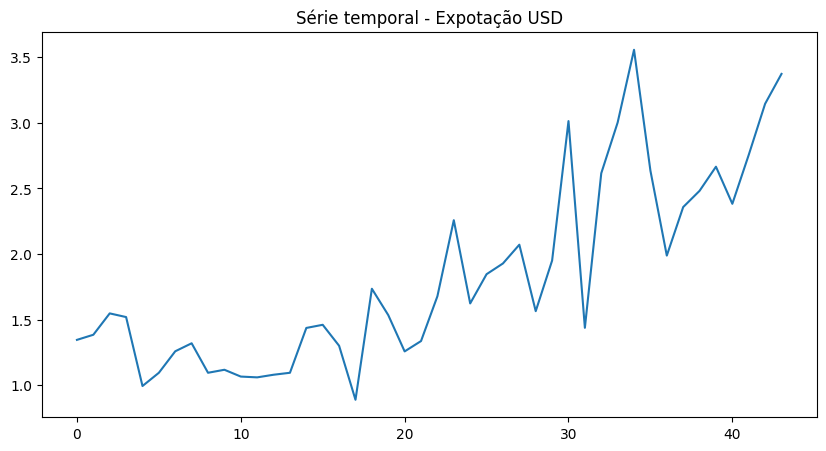

In [19]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [20]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.3984508790039688
p-value: 0.9814369176419221


**Interpretação**:

* p < 0.05 → estacionária
* p > 0.05 → precisa diferenciar (d > 0)

#### Tornar estacionário

In [ ]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.665044253301742
p-value: 0.004632585570749461


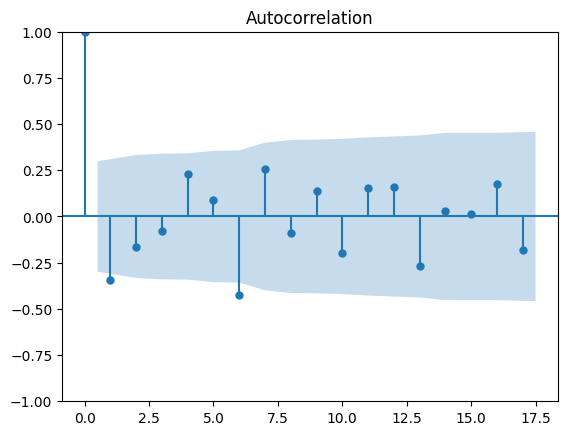

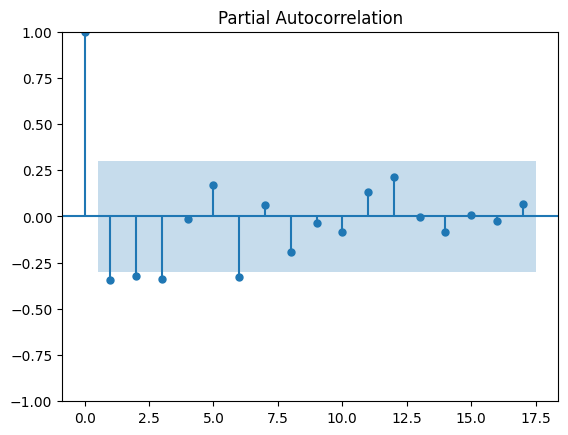

In [22]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

**Interpretação**:

* X-axis → lag
* Y-axis → força de correlação
* Pontos fora da área de confiança → correlação significativa

#### Treinamento do modelo ARIMA

In [23]:
model = ARIMA(series, order=(2, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 -25.548
Date:                Wed, 08 Apr 2026   AIC                             57.095
Time:                        17:05:55   BIC                             62.379
Sample:                             0   HQIC                            59.044
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4358      0.093     -4.665      0.000      -0.619      -0.253
ar.L2         -0.3033      0.103     -2.958      0.003      -0.504      -0.102
sigma2         0.1907      0.036      5.268      0.0

In [24]:
model = ARIMA(series, order=(3, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 -23.057
Date:                Wed, 08 Apr 2026   AIC                             56.114
Time:                        17:05:55   BIC                             64.920
Sample:                             0   HQIC                            59.362
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5589      0.402     -1.390      0.164      -1.347       0.229
ar.L2         -0.4700      0.271     -1.737      0.082      -1.000       0.060
ar.L3         -0.3345      0.236     -1.418      0.1

#### Realizando previsões

In [25]:
forecast = model_fit.forecast(steps=5)

print(forecast)

44    2.942998
45    2.946287
46    3.070754
47    3.143809
48    3.043376
Name: predicted_mean, dtype: float64


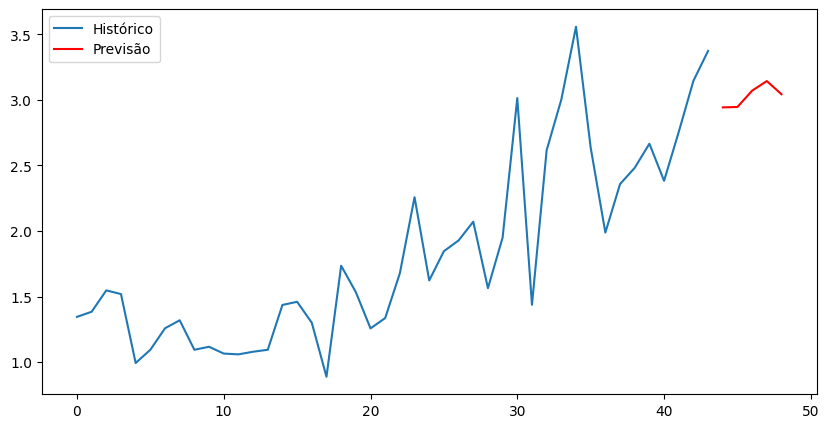

In [26]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [ ]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(2,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
print("MSE:", mse)

MSE: 0.4898374265249868


### Suíno

In [28]:
df = suino.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

,exportacao_usd
0,0.260
1,0.375
2,0.399
3,0.410
4,0.197
5,0.300
6,0.367
7,0.301
8,0.247
9,0.326


#### Visualização da série

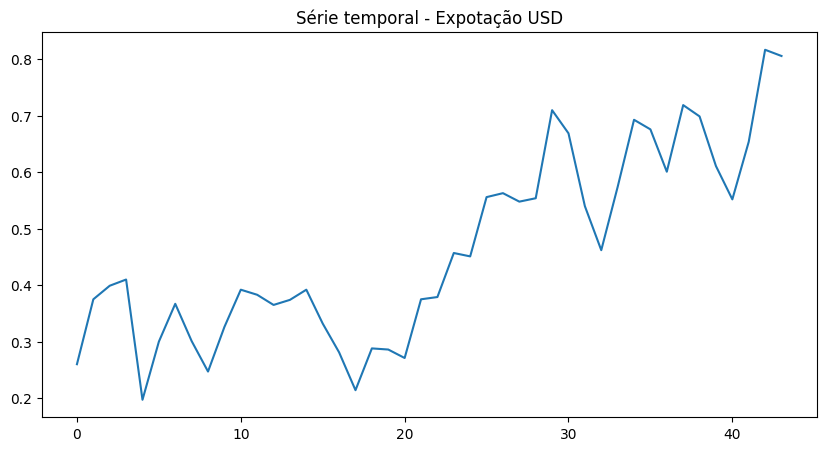

In [29]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [30]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.2634774705726149
p-value: 0.9756053880587845


#### Tornar estacionário

In [31]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.331191622176874
p-value: 0.013540492980844475


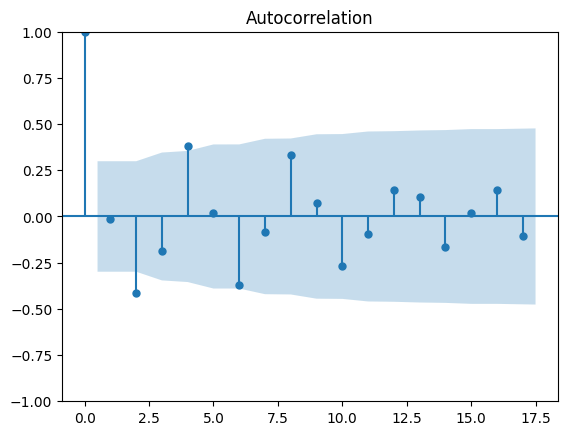

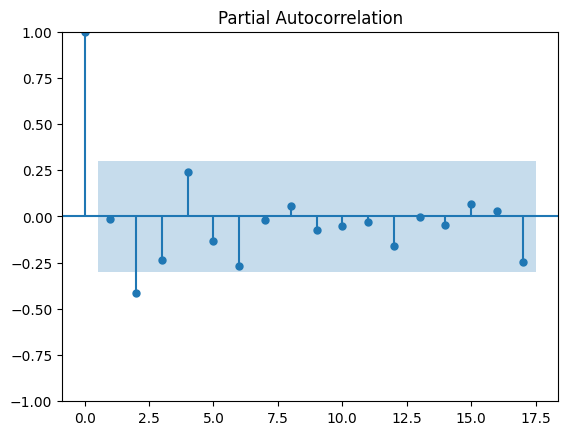

In [32]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

#### Treinamento do modelo ARIMA

In [45]:
model = ARIMA(series, order=(2, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(2, 1, 0)   Log Likelihood                  51.063
Date:                Wed, 08 Apr 2026   AIC                            -96.126
Time:                        17:29:37   BIC                            -90.842
Sample:                             0   HQIC                           -94.177
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0118      0.148      0.080      0.936      -0.278       0.301
ar.L2         -0.4313      0.185     -2.337      0.019      -0.793      -0.070
sigma2         0.0054      0.001      4.848      0.0

In [44]:
model = ARIMA(series, order=(3, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(3, 1, 0)   Log Likelihood                  52.447
Date:                Wed, 08 Apr 2026   AIC                            -96.895
Time:                        17:26:58   BIC                            -89.850
Sample:                             0   HQIC                           -94.297
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1039      0.186     -0.558      0.577      -0.469       0.261
ar.L2         -0.4457      0.177     -2.513      0.012      -0.793      -0.098
ar.L3         -0.2678      0.161     -1.662      0.0

#### Realizando previsões

In [46]:
forecast = model_fit.forecast(steps=5)

print(forecast)

44    0.735568
45    0.739482
46    0.769905
47    0.768576
48    0.755439
Name: predicted_mean, dtype: float64


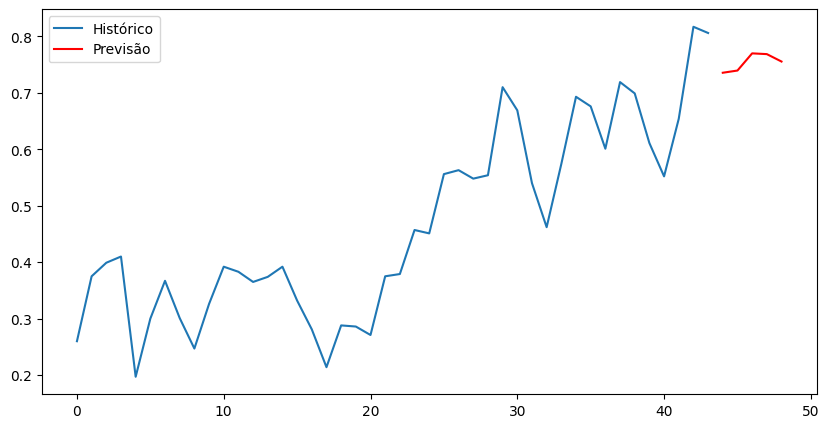

In [47]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [50]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(3,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
print("MSE:", mse)

MSE: 0.01341046484740586


### Frango

In [51]:
df = frango.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

,exportacao_usd
0,1.470
1,1.764
2,1.881
3,1.776
4,1.354
5,1.611
6,1.770
7,1.493
8,1.287
9,1.668


#### Visualização da série

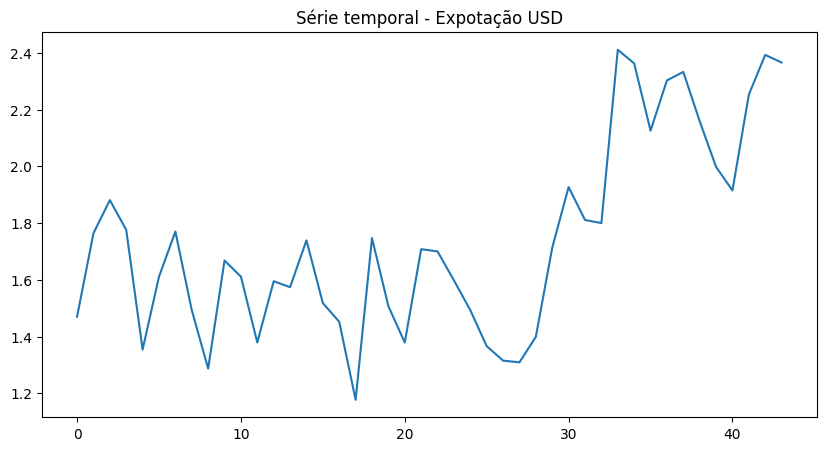

In [52]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [55]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.9829745616869845
p-value: 0.29408768971938737


#### Tornar estacionário

In [56]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -7.657738179027138
p-value: 1.7210078644384006e-11


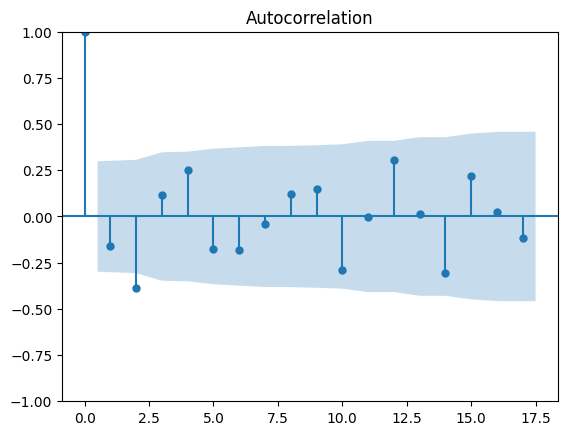

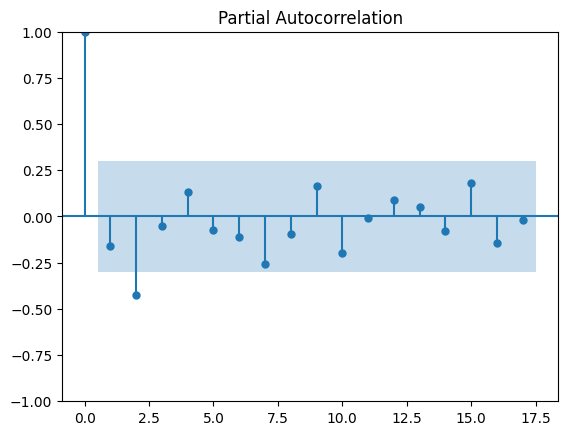

In [57]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

#### Treinamento do modelo ARIMA

In [66]:
model = ARIMA(series, order=(2, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(2, 1, 1)   Log Likelihood                   6.894
Date:                Wed, 08 Apr 2026   AIC                             -5.789
Time:                        17:37:41   BIC                              1.256
Sample:                             0   HQIC                            -3.191
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1612      0.350     -0.461      0.645      -0.847       0.525
ar.L2         -0.4135      0.226     -1.827      0.068      -0.857       0.030
ma.L1         -0.0867      0.342     -0.254      0.8

In [67]:
model = ARIMA(series, order=(2, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(2, 1, 0)   Log Likelihood                   6.845
Date:                Wed, 08 Apr 2026   AIC                             -7.689
Time:                        17:37:44   BIC                             -2.405
Sample:                             0   HQIC                            -5.741
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2315      0.159     -1.454      0.146      -0.544       0.081
ar.L2         -0.4226      0.215     -1.963      0.050      -0.845      -0.001
sigma2         0.0422      0.009      4.772      0.0

#### Realizando previsões

In [68]:
forecast = model_fit.forecast(steps=5)

print(forecast)

44    2.313082
45    2.336742
46    2.353630
47    2.339721
48    2.335803
Name: predicted_mean, dtype: float64


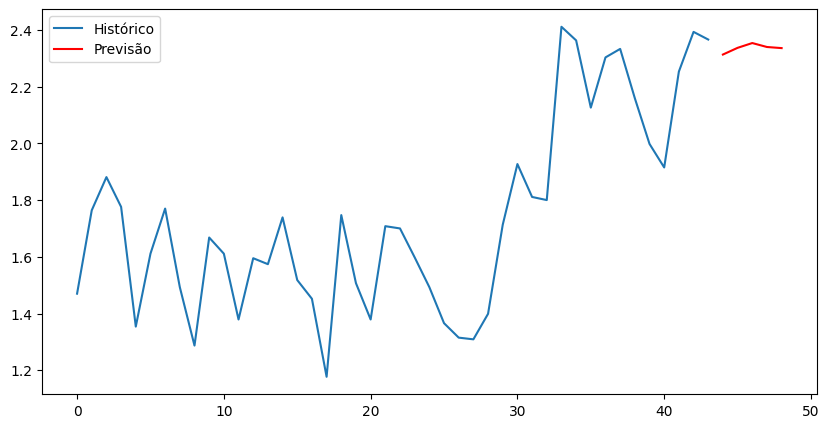

In [69]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [70]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(2,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
print("MSE:", mse)

MSE: 0.02352164940911751
